<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Adaptive Fractional Differencing (AFD)
    </h1>
  </div>
</div>

De Prado's fixed-width FFD finds the minimum differencing order `d` that
passes an **ADF** stationarity test. On finite samples that min-d-via-ADF is
biased and **under-differences**: the under-powered ADF test passes while the
series still carries spurious residual long memory. **AFD** estimates the order
directly from the data's long-memory structure (a bias-corrected Hurst blend) and
raises it to the ADF boundary only if needed.

*Baseline (min-d via ADF) -> where it breaks (under-differencing) -> AFD.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Data: adaptive_fractional_difference, adaptive_differencing_order,
    rescaled_range_hurst, find_optimal_ffd, fractional_difference_fixed

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. A strong long-memory price series
We build an integrated series with persistent increments (high Hurst), the regime
where min-d under-differences. (FRED `SP500` is the real-data analogue used by the
flagship fractional-differentiation notebook; here we keep it offline and
reproducible.)

R/S Hurst of increments = 0.715


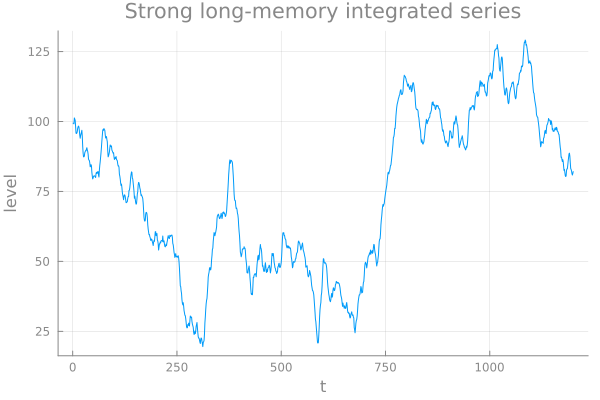

In [2]:
rng = MersenneTwister(3)
T = 1200
# persistent increments via an AR(1) with high rho -> long memory in the level
e = randn(rng, T)
incr = similar(e); incr[1] = e[1]
for t in 2:T
    incr[t] = 0.6 * incr[t-1] + e[t]
end
price = 100.0 .+ cumsum(incr)
println("R/S Hurst of increments = ", round(rescaled_range_hurst(incr), digits = 3))
plot(price; legend = false, lw = 1, xlabel = "t", ylabel = "level",
     title = "Strong long-memory integrated series")

## 2. AFD picks the order from memory, not just the ADF pass

In [3]:
res = adaptive_fractional_difference(price)
println("AFD order   d = ", round(res.order, digits = 3))
println("memory order d_hat = ", round(res.d_hat, digits = 3),
        "   ADF p-value = ", round(res.adf_pvalue, digits = 4))
println("memory retained (|corr| with level) = ", round(res.memory_retained, digits = 3))
println("CV-chosen FFD threshold = ", res.threshold)

AFD order   d = 0.717
memory order d_hat = 0.217   ADF p-value = 0.0
memory retained (|corr| with level) = 0.539
CV-chosen FFD threshold = 0.001


min-d via ADF (first d with p<=0.05) = 0.4
AFD order                            = 0.717


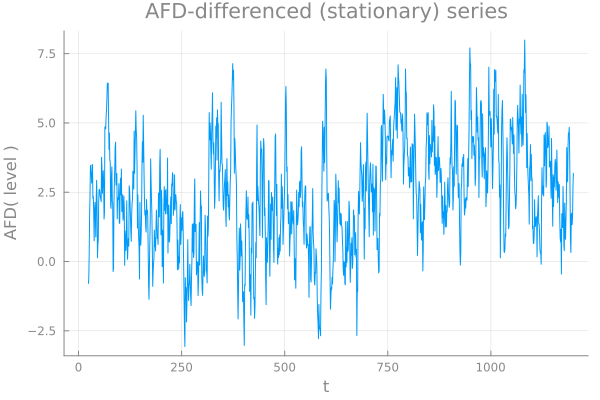

In [4]:
# Compare against de Prado's min-d FFD sweep (the ADF-only criterion).
ffd = find_optimal_ffd(price)
first_pass = findfirst(<=(0.05), ffd.p_value)
d_mindADF = first_pass === nothing ? NaN : ffd.d[first_pass]
println("min-d via ADF (first d with p<=0.05) = ", d_mindADF)
println("AFD order                            = ", round(res.order, digits = 3))
afd_series = res.series
plot(afd_series; legend = false, lw = 1, xlabel = "t",
     ylabel = "AFD( level )", title = "AFD-differenced (stationary) series")

## When to use / when NOT (from `appraisals/13_verdict.md`)
**Prefer AFD over fixed-width FFD when the differencing order itself must be
right** - strong long memory and finite samples, where min-d under-differences
(order error 0.064 vs FFD 0.371); on weak memory the gap narrows. The implemented
AFD is a tractable clean-room approximation of the published wavelet-Hurst + ridge
+ CV method; the wavelet component is optional (the Julia port uses the R/S Hurst
blend), and the ADF p-values come from `HypothesisTests`, so the exact order is
behavioural.